# Analyse bivariée et multivariée

## Objectif

Cette étape vise à étudier les relations entre les différentes variables du dataset afin de mieux comprendre les facteurs associés au rendement agricole.

L'analyse portera notamment sur :

- les relations entre variables numériques ;
- les relations entre variables catégorielles et numériques ;
- les éventuelles corrélations entre variables explicatives ;
- l'identification de tendances, groupes ou comportements atypiques ;
- la préparation des variables pertinentes avant la modélisation.


## 1. Analyse des corrélations

Une matrice de corrélation permettra d'étudier les relations linéaires entre les variables numériques.

Elle sera notamment utilisée pour observer les relations entre :

- la pluviométrie ;
- la température ;
- la durée avant récolte ;
- le rendement ;

Une attention particulière sera portée aux variables fortement corrélées entre elles afin de détecter d'éventuels phénomènes de multicolinéarité.


In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

df = pd.read_csv("../data/raw/crop_yield.csv")
numeric_df = df.select_dtypes(include="number")
cat_df = df.select_dtypes(include=["str", "bool"])

display(df.head())

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


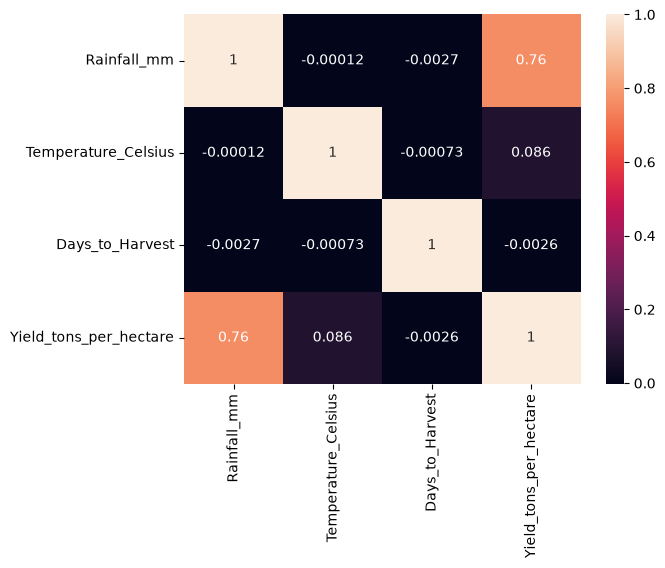

In [2]:
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True)
plt.show()

Nous constatons une corrélation:
- forte entre la *pluviométrie* `rainfall_mm` et le *rendement par hectare* `Yield_tons_per_hectare`.
- Assez légère considérant l'ensemble des corrélation entre *la température* `Temperature_Celsius` et et le *rendement par hectare* `Yield_tons_per_hectare`.

## 2. Analyse des variables catégorielles

L'influence des variables catégorielles sur le rendement sera étudiée à l'aide de représentations adaptées.

Variables concernées :

- Region ;
- Soil_Type ;
- Crop ;
- Weather_Condition ;
- Fertilizer_Used ;
- Irrigation_Used.

Des boxplots serront utilisés pour comparer la distribution du rendement entre les différentes catégories.

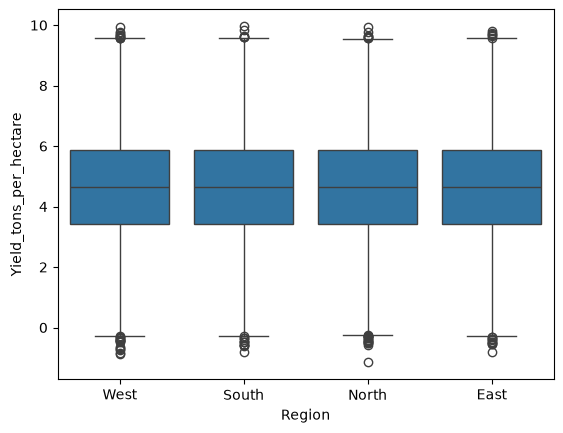

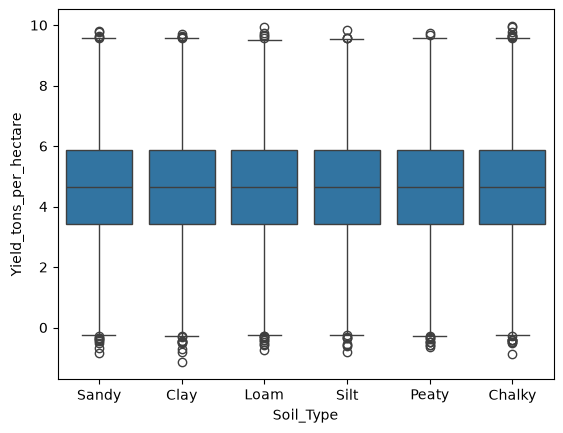

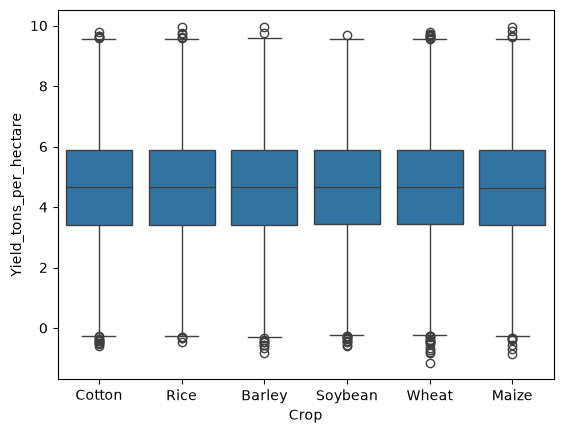

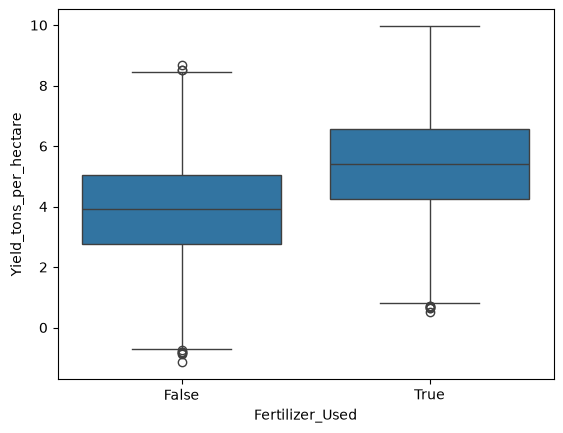

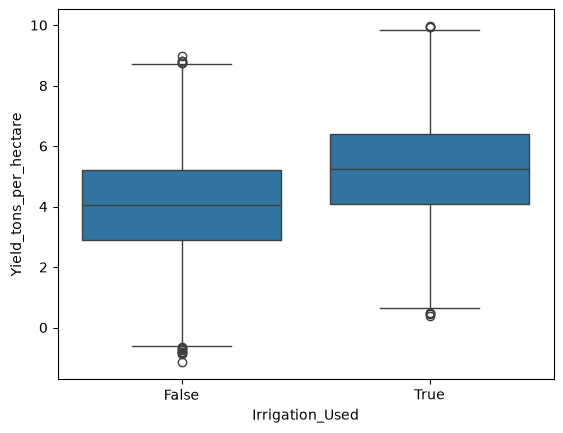

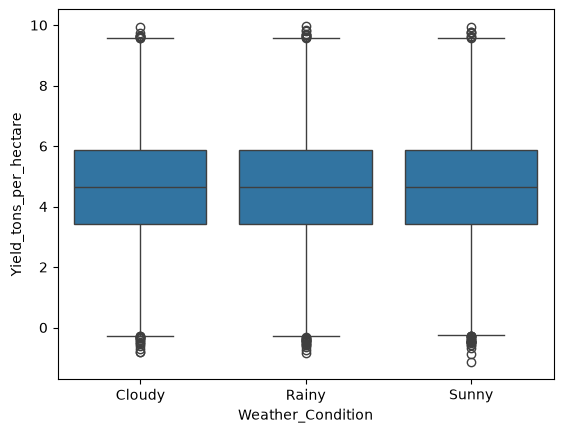

In [3]:
for col in df.columns:
    if df[col].dtype == "str" or df[col].dtype =="bool":
        sns.boxplot(
            data=df,
            x=col,
            y="Yield_tons_per_hectare"
            
        )
        plt.show()

## Interprétation des boxplots des variables catégorielles

Les boxplots permettent de comparer la distribution du rendement agricole en fonction des différentes variables catégorielles du jeu de données. L'analyse porte principalement sur la médiane, la dispersion des valeurs et la présence éventuelle de valeurs atypiques.

### Rendement en fonction de la région

Les différentes régions (`West`, `South`, `North` et `East`) présentent des distributions de rendement très similaires.

Les rendements médians sont quasiment identiques d'une région à l'autre. Les écarts interquartiles ainsi que l'étendue des distributions sont également très proches.

Visuellement, la région ne semble donc pas être associée à une différence marquée de rendement dans ce jeu de données. Des valeurs atypiques sont présentes dans chacune des régions, aussi bien parmi les rendements faibles que parmi les rendements élevés.

Cette représentation seule ne permet toutefois pas de conclure à l'absence d'un effet statistiquement significatif de la région sur le rendement.

---

### Rendement en fonction du type de sol

Les distributions du rendement sont très similaires pour les différents types de sol : `Sandy`, `Clay`, `Loam`, `Silt`, `Peaty` et `Chalky`.

Les médianes sont quasiment identiques et se situent autour de la même valeur. Les écarts interquartiles ainsi que l'étendue des distributions sont également très proches.

Visuellement, le type de sol ne semble donc pas être associé à une différence marquée de rendement dans ce jeu de données. Quelques valeurs atypiques sont présentes pour chaque type de sol, aussi bien dans les valeurs faibles que dans les valeurs élevées.

Cette représentation seule ne permet toutefois pas de conclure à l'absence d'un effet statistiquement significatif du type de sol sur le rendement.

---

### Rendement en fonction de la culture

Les différentes cultures (`Cotton`, `Rice`, `Barley`, `Soybean`, `Wheat` et `Maize`) présentent également des distributions très similaires.

Les rendements médians sont pratiquement identiques entre les cultures et la dispersion des observations reste comparable.

Le graphique ne met donc pas en évidence de culture présentant un rendement globalement supérieur ou inférieur aux autres dans ce dataset.

Cela peut indiquer que la variable `Crop`, prise isolément, ne permet pas d'expliquer une part importante de la variation du rendement. Il sera néanmoins pertinent d'étudier les interactions entre la culture et d'autres variables comme les précipitations, la température, l'irrigation ou l'utilisation de fertilisants.

---

### Rendement en fonction de l'utilisation de fertilisants

Une différence nettement plus importante apparaît lorsque l'on compare les parcelles avec et sans utilisation de fertilisants.

La médiane du rendement est plus élevée lorsque `Fertilizer_Used = True` que lorsque `Fertilizer_Used = False`.

La distribution entière semble également décalée vers des valeurs de rendement plus importantes dans le groupe utilisant des fertilisants.

Cette représentation suggère donc une association positive entre l'utilisation de fertilisants et le rendement agricole.

Cependant, ce graphique ne permet pas à lui seul d'affirmer que les fertilisants sont la cause directe de cette augmentation. D'autres variables peuvent intervenir simultanément dans le niveau de rendement.

---

### Rendement en fonction de l'irrigation

L'utilisation de l'irrigation présente également une différence visible.

Les parcelles pour lesquelles `Irrigation_Used = True` possèdent un rendement médian supérieur à celles pour lesquelles l'irrigation n'est pas utilisée.

Les deux distributions sont clairement décalées, avec des rendements généralement plus élevés pour les observations utilisant l'irrigation.

L'irrigation semble donc être une variable particulièrement intéressante pour expliquer le rendement dans ce jeu de données.

Comme pour les fertilisants, cette observation correspond à une association statistique visible dans les données et ne permet pas encore d'établir une relation de causalité.

---

### Rendement en fonction des conditions météorologiques

Les distributions correspondant aux conditions `Cloudy`, `Rainy` et `Sunny` sont presque identiques.

Les médianes sont très proches et la dispersion des valeurs est comparable dans les trois catégories.

La variable `Weather_Condition` ne semble donc pas, prise isolément, être associée à une variation importante du rendement.

Ce résultat ne signifie toutefois pas nécessairement que les conditions climatiques n'ont aucune influence. Des variables numériques plus précises, comme la température ou la quantité de précipitations, peuvent contenir davantage d'information que cette classification générale de la météo.

---

## Synthèse

L'analyse visuelle des boxplots permet de distinguer deux groupes de variables.

Les variables `Region`, `Soil_Type`, `Crop` et `Weather_Condition` présentent des distributions de rendement très similaires entre leurs différentes catégories. Aucun effet important n'est immédiatement visible sur ces graphiques.

À l'inverse, les variables `Fertilizer_Used` et `Irrigation_Used` montrent des différences beaucoup plus marquées. Les observations utilisant des fertilisants ou l'irrigation présentent des rendements médians plus élevés.

Ces premiers résultats suggèrent donc que l'irrigation et l'utilisation de fertilisants pourraient constituer des variables importantes pour expliquer le rendement. Ces observations devront être complétées par l'analyse des variables numériques, l'étude des interactions entre variables et, si nécessaire, par des tests statistiques afin de déterminer si les différences observées sont statistiquement significatives.


---
### Encodage des variables booléennes

Vu les problèmes rencontrés par les précédentes explorations de notre fichier, entre autre la faible corrélation entre les variables explicatives, nous allons encoder les variables binaires afin de les utiliser comme variable numériques dans le but d'augmenter nos variables.

In [10]:
#Encodage des variables booleénnes
numeric_df["Irrigation_Used"] = df["Irrigation_Used"].astype(int)
numeric_df["Fertilizer_Used"] = df["Fertilizer_Used"].astype(int)

display(numeric_df.tail(5))


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare,Irrigation_Used,Fertilizer_Used
999995,302.805345,27.987428,76,1.347586,0,0
999996,932.991383,39.661039,93,7.311594,0,1
999997,867.362046,24.370042,108,5.763182,0,1
999998,492.812857,33.045505,102,2.070159,0,0
999999,180.936180,27.298847,76,2.937243,0,1



---
# ACP
Nous allons résumer les variables numériques corrélées en quelques nouvelles dimensions appelées composantes principales.
Nous allons utiliser nos variables numériques qui sont :
- Rainfall_mm	
- Temperature_Celsius
- Days_to_Harvest	

Nous utiliserons `Yield_tons_per_hectare` comme variable illustrative pour pouvoir interpréter nos résultats

In [11]:
display(numeric_df)

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare,Irrigation_Used,Fertilizer_Used
0,897.077239,27.676966,122,6.555816,1,0
1,992.673282,18.026142,140,8.527341,1,1
2,147.998025,29.794042,106,1.127443,0,0
3,986.866331,16.644190,146,6.517573,1,0
4,730.379174,31.620687,110,7.248251,1,1
...,...,...,...,...,...,...
999995,302.805345,27.987428,76,1.347586,0,0
999996,932.991383,39.661039,93,7.311594,0,1
999997,867.362046,24.370042,108,5.763182,0,1
999998,492.812857,33.045505,102,2.070159,0,0


In [13]:
X = numeric_df.drop(columns=["Yield_tons_per_hectare"])

display(X)

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Irrigation_Used,Fertilizer_Used
0,897.077239,27.676966,122,1,0
1,992.673282,18.026142,140,1,1
2,147.998025,29.794042,106,0,0
3,986.866331,16.644190,146,1,0
4,730.379174,31.620687,110,1,1
...,...,...,...,...,...
999995,302.805345,27.987428,76,0,0
999996,932.991383,39.661039,93,0,1
999997,867.362046,24.370042,108,0,1
999998,492.812857,33.045505,102,0,0


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Standardiser les variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Appliquer l'ACP
pca = PCA()
pca.fit(X_scaled)

print(f"Moyenne {X_scaled.mean(axis=0)}, écart type {X_scaled.std(axis=0)}")



Moyenne [-6.73480827e-16 -5.98049610e-16  6.74162948e-17 -5.88897819e-17
 -9.04947228e-17], écart type [1. 1. 1. 1. 1.]


In [15]:
pca.explained_variance_ratio_

array([0.20068084, 0.20050277, 0.20011696, 0.19939034, 0.19930909])

In [16]:
pca.explained_variance_ratio_.cumsum()

array([0.20068084, 0.40118361, 0.60130058, 0.80069091, 1.        ])

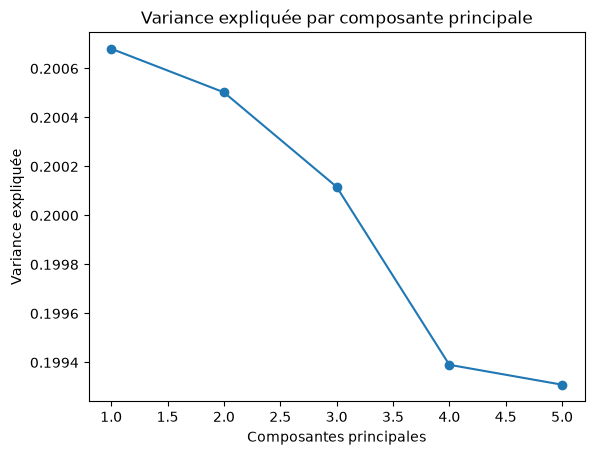

In [17]:
variance = pca.explained_variance_ratio_
components = range(1, len(variance) + 1)
plt.plot(
    components,
    variance,
    marker="o"
)

plt.xlabel("Composantes principales")
plt.ylabel("Variance expliquée")
plt.title("Variance expliquée par composante principale")
plt.show()